# Example of 2 limbs connected to neural network

## Ручное задание системы с двумя конечностями

In [6]:
"""
Модуль для явного создания и тестирования нейромеханической системы из двух конечностей.
Module for explicit creation and testing of a two-limb neuromechanical system.
"""

import numpy as np
import matplotlib.pyplot as plt
from SpikingNN.core.multi_limb import MultiLimbSystem
from SpikingNN.core.Izh_net import (
    Izhikevich_IO_Network,
    Afferented_Limb,
    SimpleAdaptedMuscle,
    OneDOFLimb,
    types2params
)
np.random.seed(42)

def create_limb(name: str) -> Afferented_Limb:
    """
    Создает стандартную конечность с одной степенью свободы.
    Creates a standard one-degree-of-freedom limb.

    Args:
        name (str): Имя конечности для идентификации. / Name of the limb for identification.

    Returns:
        Afferented_Limb: Настроенный объект конечности. / Configured limb object.
    """
    flexor = SimpleAdaptedMuscle(w=0.5, N=5, tau_c=39, tau_1=21)
    extensor = SimpleAdaptedMuscle(w=0.5, N=5, tau_c=39, tau_1=21)
    limb_mech = OneDOFLimb(m=0.3, ls=0.3, b=0.01, q0=np.pi/2, a1=0.06, a2=0.007)
    return Afferented_Limb(Limb=limb_mech, Flexor=flexor, Extensor=extensor)

def get_2_limbs_matrices():
    """
    Формирует полноценные матрицы соединений для системы из 2 конечностей.
    Forms full connection matrices for a 2-limb system.
    
    Структура нейронов (8 шт):
    0: CPG_L_F, 1: MN_L_F, 2: CPG_L_E, 3: MN_L_E (Левая конечность)
    4: CPG_R_F, 5: MN_R_F, 6: CPG_R_E, 7: MN_R_E (Правая конечность)
    
    Returns:
        dict: Словарь с матрицами Q_app, Q_aff, P, W, tau_syn и именами.
              Dictionary with matrices Q_app, Q_aff, P, W, tau_syn and names.
    """
    N = 8
    input_size = 2
    output_size = 4
    afferent_size = 12
    
    names = [
        "CPG_L_F", "MN_L_F", "CPG_L_E", "MN_L_E",
        "CPG_R_F", "MN_R_F", "CPG_R_E", "MN_R_E"
    ]
    types = ['CH', 'FS', 'CH', 'FS', 'CH', 'FS', 'CH', 'FS']
    
    # Матрица распределения внешнего входного тока (8x2)
    # Ток подается только на CPG_F левой и правой ноги
    Q_app = np.array([
        [1.5, 0.0],  # 0: CPG_L_F <- Input 0
        [0.0, 0.0],  # 1: MN_L_F
        [1.0, 0.0],  # 2: CPG_L_E
        [0.0, 0.0],  # 3: MN_L_E
        [0.0, 1.0],  # 4: CPG_R_F <- Input 1
        [0.0, 0.0],  # 5: MN_R_F
        [0.0, 1.5],  # 6: CPG_R_E
        [0.0, 0.0]   # 7: MN_R_E
    ])
    
    # Матрица афферентной обратной связи (8x12)
    # Для чистоты эксперимента оставляем нулевой (сеть работает на внешнем токе)
    Q_aff = np.array( [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.8, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.8, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8, 0.3, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8, 0.3, 0.0]
    ])
    
    # Матрица вывода на мышцы (4x8)
    # Выходы: 0: Flex_L, 1: Ext_L, 2: Flex_R, 3: Ext_R
    P = np.array([
        [0, 1, 0, 0, 0, 0, 0, 0],  # 0: Flex_L <- MN_L_F (idx 1)
        [0, 0, 0, 1, 0, 0, 0, 0],  # 1: Ext_L  <- MN_L_E (idx 3)
        [0, 0, 0, 0, 0, 1, 0, 0],  # 2: Flex_R <- MN_R_F (idx 5)
        [0, 0, 0, 0, 0, 0, 0, 1]   # 3: Ext_R  <- MN_R_E (idx 7)
    ])
    
    # Матрица синаптических весов внутри сети (8x8)
    # Структура: CPG_F -> MN_F (возбуждение), CPG_E -> MN_E (возбуждение)
    #            CPG_F <-> CPG_E (взаимное торможение)
    W = np.array([
        #  CPG_L_F  MN_L_F  CPG_L_E  MN_L_E  CPG_R_F  MN_R_F  CPG_R_E  MN_R_E
        [  0.0,      0.0,    -1.5,     0.0,     0.0,     0.0,     0.0,     0.0 ], # 0: CPG_L_F (тормозится CPG_L_E)
        [  1.5,      0.0,     0.0,     0.0,     0.0,     0.0,     0.0,     0.0 ], # 1: MN_L_F  (возбуждается CPG_L_F)
        [ -1.5,      0.0,     0.0,     0.0,     0.0,     0.0,     0.0,     0.0 ], # 2: CPG_L_E (тормозится CPG_L_F)
        [  0.0,      0.0,     1.5,     0.0,     0.0,     0.0,     0.0,     0.0 ], # 3: MN_L_E  (возбуждается CPG_L_E)
        [  0.0,      0.0,     0.0,     0.0,     0.0,     0.0,    -1.5,     0.0 ], # 4: CPG_R_F (тормозится CPG_R_E)
        [  0.0,      0.0,     0.0,     0.0,     1.5,     0.0,     0.0,     0.0 ], # 5: MN_R_F  (возбуждается CPG_R_F)
        [  0.0,      0.0,     0.0,     0.0,    -1.5,     0.0,     0.0,     0.0 ], # 6: CPG_R_E (тормозится CPG_R_F)
        [  0.0,      0.0,     0.0,     0.0,     0.0,     0.0,     1.5,     0.0 ]  # 7: MN_R_E  (возбуждается CPG_R_E)
    ])
    
    # Матрица времен релаксации синапсов (8x8)
    tau_syn = 20 * np.ones((N, N))
    
    return {
        "names": names,
        "types": types,
        "Q_app": Q_app,
        "Q_aff": Q_aff,
        "P": P,
        "W": W,
        "tau_syn": tau_syn,
        "N": N,
        "input_size": input_size,
        "output_size": output_size,
        "afferent_size": afferent_size
    }

def run_2_limbs_simulation():
    """
    Запуск симуляции и визуализации для системы из 2 конечностей.
    Runs simulation and visualization for a 2-limb system.
    """
    print("🚀 Инициализация системы из 2 конечностей... / Initializing 2-limb system...")
    
    # 1. Получаем явные матрицы
    matrices = get_2_limbs_matrices()
    A, B, C, D = types2params(matrices["types"])
    
    # 2. Создаем сеть
    net = Izhikevich_IO_Network(
        N=matrices["N"], 
        input_size=matrices["input_size"], 
        output_size=matrices["output_size"],
        afferent_size=matrices["afferent_size"], 
        names=matrices["names"],
        Q_app=matrices["Q_app"], 
        Q_aff=matrices["Q_aff"], 
        P=matrices["P"]
    )
    net.set_params(a=A, b=B, c=C, d=D)
    net.M = np.ones((matrices["N"], matrices["N"])) # Полная маска связности
    net.set_weights(matrices["W"])
    net.set_synaptic_relax_constant(matrices["tau_syn"])
    
    # 3. Создаем 2 конечности
    limb_names = ["Left_Limb", "Right_Limb"]
    limbs = [create_limb(name) for name in limb_names]
        
    # 4. Собираем систему
    system = MultiLimbSystem(network=net, limbs=limbs, names=limb_names)
    
    # 5. Параметры симуляции
    T_sim = 3000  # ms
    dt = 0.1      # ms
    steps = int(T_sim / dt)
    
    # Входной ток: стимулируем обе ноги
    Iapp = np.array([8.0, 10.0]) 
    
    # Буферы
    time_vec = np.arange(steps) * dt
    V_hist = np.zeros((steps, matrices["N"]))
    F_flex_hist = {name: np.zeros(steps) for name in limb_names}
    F_ext_hist = {name: np.zeros(steps) for name in limb_names}
    q_hist = {name: np.zeros(steps) for name in limb_names}
    
    print("✅ Система собрана. Запуск цикла симуляции... / System assembled. Starting simulation...")
    
    for i in range(steps):
        V_hist[i] = system.net.V_prev
        for j, name in enumerate(limb_names):
            F_flex_hist[name][i] = system.limbs[j].F_flex
            F_ext_hist[name][i] = system.limbs[j].F_ext
            q_hist[name][i] = system.limbs[j].q
            
        system.step(dt=dt, Iapp=Iapp)
        
        if i % 1000 == 0 and np.any(np.isnan(system.net.V_prev)):
            print(f"⚠️ Обнаружены NaN на шаге {i}! / NaN detected at step {i}!")
            break
            
    print("✅ Симуляция завершена. / Simulation finished.")

    
    # 7. Визуализация результатов симуляции
    fig = plt.figure(figsize=(12, 11))
    fig.suptitle("2-Limb Neuromechanical System Simulation / Симуляция нейромеханической системы из 2 конечностей", fontsize=16)
    
    # --- График 1: Потенциалы мембран нейронов ---
    ax1 = plt.subplot(3, 1, 1)
    for neuron_idx in range(matrices["N"]):
        ax1.plot(time_vec, V_hist[:, neuron_idx], label=matrices["names"][neuron_idx], linewidth=0.8)
    ax1.set_title("Neuron Membrane Potentials / Потенциалы мембран нейронов")
    ax1.set_ylabel("V (mV)")
    ax1.legend(ncol=4, fontsize=8, loc='upper right')
    ax1.grid(True)
    
    # --- График 2: Силы мышц ---
    ax2 = plt.subplot(3, 1, 2)
    colors = ['blue', 'red']
    for idx, name in enumerate(limb_names):
        ax2.plot(time_vec, F_flex_hist[name], label=f"{name}_Flex", color=colors[idx], linestyle='-')
        ax2.plot(time_vec, F_ext_hist[name], label=f"{name}_Ext", color=colors[idx], linestyle='--')
    ax2.set_title("Muscle Forces / Силы мышц")
    ax2.set_ylabel("Force (N)")
    ax2.legend(ncol=2, fontsize=10)
    ax2.grid(True)
    
    # --- График 3: Углы конечностей ---
    ax3 = plt.subplot(3, 1, 3)
    for idx, name in enumerate(limb_names):
        ax3.plot(time_vec, q_hist[name], label=name, color=colors[idx], linewidth=2)
    ax3.set_title("Limb Angles / Углы конечностей")
    ax3.set_ylabel("Angle (rad)")
    ax3.set_xlabel("Time (ms)")
    ax3.legend(fontsize=10)
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    return q_hist, time_vec

## Задание системы через config

In [7]:
"""
Скрипт для запуска и визуализации нейромеханической системы из 2 конечностей через API.
Script to run and visualize a 2-limb neuromechanical system via the SpikingNN API.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from SpikingNN.api import create_simulation

def run_and_visualize(config_path: str):
    """
    Загружает конфигурацию, инициализирует систему через API, 
    запускает симуляцию и строит графики.
    
    Loads config, initializes system via API, runs simulation, and plots results.
    
    Args:
        config_path (str): Путь к JSON файлу конфигурации. / Path to the JSON config file.
    """
    print(f"🚀 Загрузка конфигурации из {config_path}... / Loading config from {config_path}...")
    
    # 1. Сборка системы через API (используем фабрики и валидацию)
    sim = create_simulation(config_path)
    print(f"✅ Система собрана. Тип: {sim.system_type}, Нейронов: {sim.network.N}")
    
    # 2. Извлечение параметров симуляции из конфига
    dt = sim.config["simulation"]["dt"]
    duration = sim.config["simulation"]["duration"]
    steps = int(duration / dt)
    time_vec = np.arange(steps) * dt
    
    # Извлечение входного тока
    input_cfg = sim.config["simulation"].get("input_current", {})
    amplitudes = input_cfg.get("amplitude", [])
    input_indices = input_cfg.get("neurons", [0, 1]) # Индексы входов (0 и 1)
    
    Iapp = np.zeros(sim.network.input_size)
    for idx in input_indices:
        if idx < sim.network.input_size:
            Iapp[idx] = amplitudes[idx]
            
    # 3. Инициализация буферов для истории
    N = sim.network.N
    V_hist = np.zeros((steps, N))
    
    limb_names = [limb_cfg["name"] for limb_cfg in sim.config["limbs"]]
    F_flex_hist = {name: np.zeros(steps) for name in limb_names}
    F_ext_hist = {name: np.zeros(steps) for name in limb_names}
    q_hist = {name: np.zeros(steps) for name in limb_names}
    
    print("✅ Запуск цикла симуляции... / Starting simulation loop...")
    
    # 4. Цикл симуляции
    # Примечание: Мы используем ручной цикл, так как текущий класс Results в api.py 
    # сохраняет только V и U, но нам нужна история механики конечностей для графиков.
    # Note: We use a manual loop because the current Results class in api.py 
    # only saves V and U, but we need limb mechanics history for plotting.
    for i in range(steps):
        # Сохранение состояния
        V_hist[i] = sim.network.V_prev
        for j, name in enumerate(limb_names):
            F_flex_hist[name][i] = sim.system.limbs[j].F_flex
            F_ext_hist[name][i] = sim.system.limbs[j].F_ext
            q_hist[name][i] = sim.system.limbs[j].q
            
        # Шаг системы
        sim.system.step(dt=dt, Iapp=Iapp)
        
        if i % 1000 == 0 and np.any(np.isnan(sim.network.V_prev)):
            print(f"⚠️ Обнаружены NaN на шаге {i}! / NaN detected at step {i}!")
            break
            
    print("✅ Симуляция завершена. / Simulation finished.")
    
    # 5. Визуализация результатов
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle("2-Limb System via API / Система из 2 конечностей через API", fontsize=16)
    
    # --- График 1: Потенциалы мембран (или Растр) ---
    ax1 = plt.subplot(3, 1, 1)
    for neuron_idx in range(N):
        ax1.plot(time_vec, V_hist[:, neuron_idx], label=sim.network.names[neuron_idx], linewidth=0.8)
    ax1.set_title("Neuron Membrane Potentials / Потенциалы мембран нейронов")
    ax1.set_ylabel("V (mV)")
    ax1.legend(ncol=4, fontsize=8, loc='upper right')
    ax1.grid(True)
    
    # --- График 2: Силы мышц ---
    ax2 = plt.subplot(3, 1, 2)
    colors = ['blue', 'red']
    for idx, name in enumerate(limb_names):
        ax2.plot(time_vec, F_flex_hist[name], label=f"{name}_Flex", color=colors[idx], linestyle='-')
        ax2.plot(time_vec, F_ext_hist[name], label=f"{name}_Ext", color=colors[idx], linestyle='--')
    ax2.set_title("Muscle Forces / Силы мышц")
    ax2.set_ylabel("Force (N)")
    ax2.legend(ncol=2, fontsize=10)
    ax2.grid(True)
    
    # --- График 3: Углы конечностей ---
    ax3 = plt.subplot(3, 1, 3)
    for idx, name in enumerate(limb_names):
        ax3.plot(time_vec, q_hist[name], label=name, color=colors[idx], linewidth=2)
    ax3.set_title("Limb Angles / Углы конечностей")
    ax3.set_ylabel("Angle (rad)")
    ax3.set_xlabel("Time (ms)")
    ax3.legend(fontsize=10)
    ax3.grid(True)
    
    plt.tight_layout()
    return q_hist, time_vec

🚀 Загрузка конфигурации из 2Limb_config.json... / Loading config from 2Limb_config.json...
✅ Система собрана. Тип: fullsys, Нейронов: 8
✅ Запуск цикла симуляции... / Starting simulation loop...
✅ Симуляция завершена. / Simulation finished.
🚀 Инициализация системы из 2 конечностей... / Initializing 2-limb system...
✅ Система собрана. Запуск цикла симуляции... / System assembled. Starting simulation...
✅ Симуляция завершена. / Simulation finished.


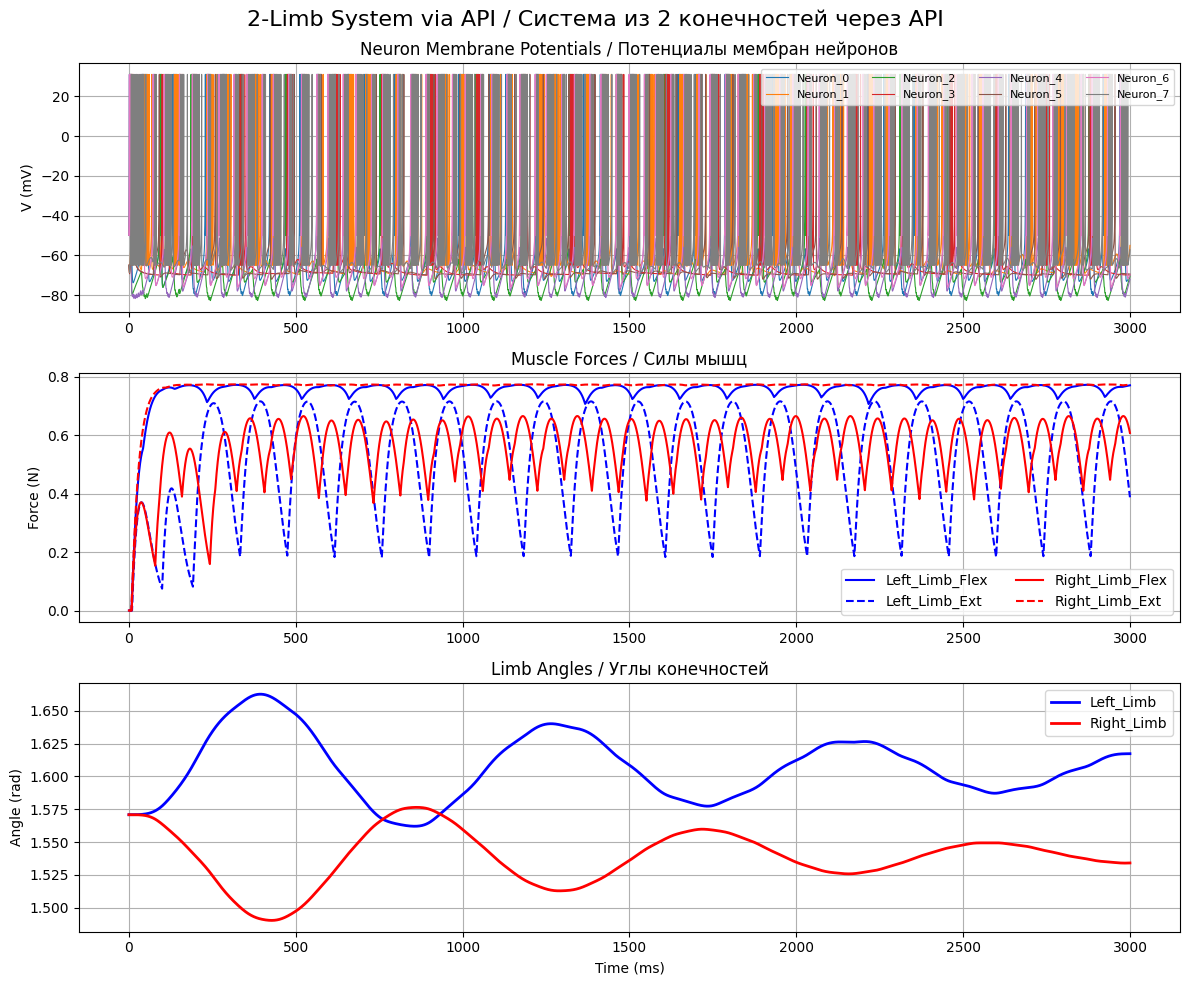

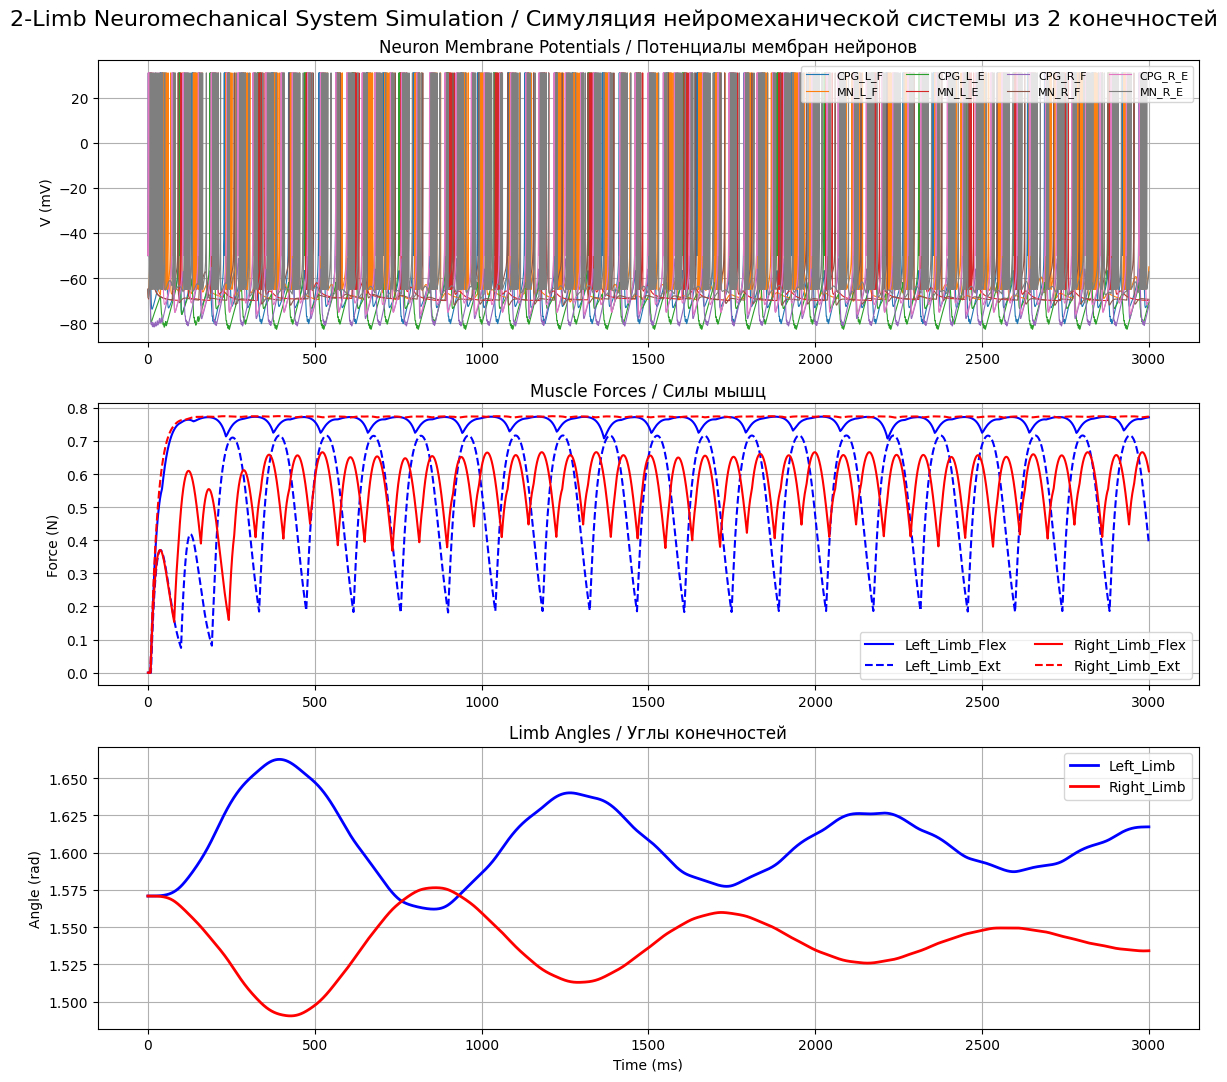

dict_keys(['Left_Limb', 'Right_Limb'])
dict_keys(['Left_Limb', 'Right_Limb'])


In [8]:
# api returns
q_hist_api, t_api = run_and_visualize("2Limb_config.json")

# mu;tilimb code returns
q_hist_my, t_my = run_2_limbs_simulation()
print(q_hist_api.keys())
print(q_hist_api.keys())

[ 3.67320510e-06  3.67320510e-06  3.67320330e-06 ... -4.42606126e-07
 -4.42965077e-07 -4.43323766e-07]


[]

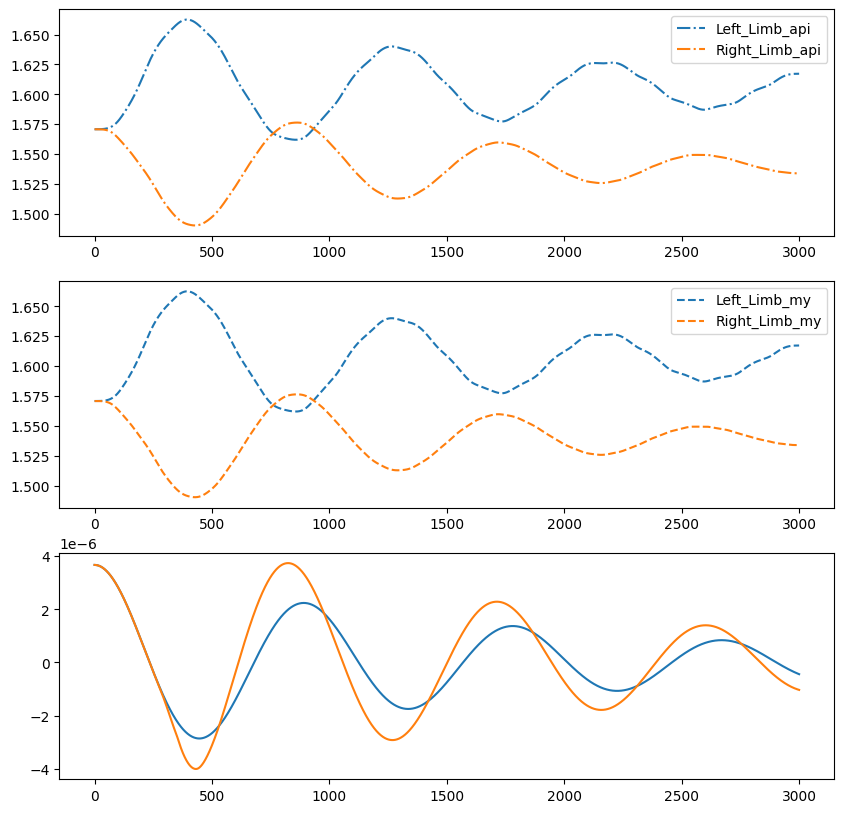

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10, 10))
for key in q_hist_api.keys():
    ax1.plot(t_api, q_hist_api[key], label=f"{key}_api", linestyle='-.')
for key in q_hist_my.keys():
    ax2.plot(t_api, q_hist_my[key], label=f"{key}_my", linestyle='--')
ax1.legend()
ax2.legend()
# errors
err_left = q_hist_api['Left_Limb']-q_hist_my['Left_Limb']
print(err_left)
err_right = q_hist_api['Right_Limb']-q_hist_my['Right_Limb']
ax3.plot(t_api, err_left)
ax3.plot(t_api, err_right)

plt.plot()